# Disk Space and Running Time Warning

This notebook takes approximately **30-35 minutes** to run fully on a T4 GPU and requires approximately **1 GB** of free disk space for the image decoding process. Ensure your drive (Google Drive if running on Colab) has enough space before running the decoding cells to avoid interruptions.

- **Test set decoded images**: ~ 750 MB (~1,000 images)
- **Model + latents**: ~ 50 MB

Each decoded image is ~0.75 MB (256×256 RGB). Files are saved as PyTorch tensors (.pt) in batches.

# Notebook 3: Low-Level Image Reconstruction from fMRI

In this notebook, we build a minimal low-level decoding baseline that predicts *image appearance* from fMRI by mapping voxel patterns to a compressed visual latent space.

## What You Will Learn

By the end of this tutorial, you'll understand how to take raw fMRI voxels and produce actual image reconstructions. The key insight is that we don't predict pixels directly—instead, we predict a compressed representation that a pre-trained image decoder can turn back into pictures.

We'll work through the complete pipeline: loading NSD data, encoding images into VAE latents, fitting two different decoders (linear and nonlinear), and evaluating how well they recover visual information from brain activity.

## What This Tutorial Is

This is **low-level reconstruction**, we're recovering color and coarse spatial structure, not semantic content. There's no text prior, no diffusion sampling, and no semantic guidance here. Think of this as establishing a baseline: how much can we recover with relatively simple methods?


In [ ]:
!pip -q install diffusers transformers accelerate pytorch_msssim kornia webdataset braceexpand


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 54.4 MB/s eta 0:00:00


## Setup and Dependencies

We'll need several libraries for this tutorial: PyTorch for modeling, Diffusers for the VAE, and specialized packages for metrics and data loading. The install cell below handles everything.

In [ ]:
# Standard libs
import os
from pathlib import Path
from typing import Tuple, Optional

# Numeric + torch
import numpy as np
import torch

# Download + dataset streaming
import braceexpand
import webdataset as wds
from dataclasses import dataclass

# Progress bars + plotting (only if you actually plot)
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

## Reproducibility

Setting random seeds ensures our results are reproducible across runs. This matters for science—you want to know that differences between models come from the models themselves, not from random initialization or data shuffling.

In [ ]:
#Seeding is important for reproducibility
import random
import os

def set_seed(seed: int) -> None:
    """Set all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make CUDA operations deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
from dataclasses import dataclass

@dataclass(frozen=True)
class LowLevelCfg:
    subject_id: int = 1
    seed: int = 42

    # streaming
    batch_size: int = 64
    num_workers: int = 4    # Increased to 4 for faster downloads

    # low-level target
    img_size: int = 256
    vae_id: str = "stabilityai/sd-vae-ft-mse"  # SD VAE

    # ridge - lower alpha = less shrinkage = more variance in predictions
    ridge_alpha: float = 1e5

ll = LowLevelCfg()
print(ll)


LowLevelCfg(subject_id=1, seed=42, batch_size=64, num_workers=4, img_size=256, vae_id='stabilityai/sd-vae-ft-mse', ridge_alpha=100000.0)


## Configuration

We centralize all hyperparameters in a configuration object. This makes the tutorial easy to modify and rerun with different settings.

Key parameters to understand:
- **vae_id**: Which VAE defines the latent space we're predicting into
- **img_size**: Resolution for decoding and evaluation (256×256)
- **ridge_alpha**: Regularization strength for the linear baseline (higher = more regularization)

## Streaming Data Loading

The NSD dataset is too large to download entirely, so we use **streaming data loading** with WebDataset. This approach fetches data on-demand from HuggingFace, ensuring only the batches currently being processed are held in memory.

The `build_nsd_dataset` function creates this pipeline: it downloads shards from HuggingFace, decodes compressed data containing images, voxels, and trial IDs, batches samples for efficient processing, and shuffles training data. This lets us work with datasets that far exceed available memory.

In [ ]:
PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results"
CACHE_DIR = PROJECT_DIR / "cache"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"RESULTS_DIR: {RESULTS_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")



RESULTS_DIR: /content/results
CACHE_DIR: /content/cache


In [ ]:
def voxel_select(voxels: torch.Tensor, mode: str = "mean") -> torch.Tensor:
    """
    Combine repeated voxel responses into a single vector.

    Args:
        voxels: Tensor of shape [B, V] (already selected) or [B, R, V] (R repeats)
        mode: "mean" to average repeats (default and only mode used in this notebook)

    Returns:
        Tensor of shape [B, V]
    """
    if voxels.ndim == 2:
        return voxels  # Already [B, V]

    if voxels.ndim != 3:
        raise ValueError(f"voxels must have shape [B,V] or [B,R,V], got {tuple(voxels.shape)}")

    # Average across repeats (dim=1)
    return voxels.mean(dim=1)

In [ ]:
# Helper to build the streaming dataset
def build_nsd_dataset(
    subject_id: int,
    split: str,
    batch_size: int,
    seed: int = 42  # Add seed parameter for deterministic shuffle
):
    """
    Creates a streaming WebDataset pipeline.
    split: 'train', 'val', or 'test'
    seed: Random seed for deterministic shuffling (train split only)
    """
    # Use 'resolve' for direct file access
    base_url = "https://huggingface.co/datasets/pscotti/naturalscenesdataset/resolve/main/webdataset_avg_new"

    if split == "train":
        # pattern: train/train_subj0X_{0..17}.tar
        url_pattern = f"{base_url}/train/train_subj0{subject_id}_{{0..17}}.tar"
    elif split == "val":
        # pattern: val/val_subj0X_0.tar
        url_pattern = f"{base_url}/val/val_subj0{subject_id}_0.tar"
    elif split == "test":
        # pattern: test/test_subj0X_{0..1}.tar
        url_pattern = f"{base_url}/test/test_subj0{subject_id}_{{0..1}}.tar"
    else:
        raise ValueError(f"Unknown split: {split}")

    urls = list(braceexpand.braceexpand(url_pattern))

    # Use shardshuffle=False to ensure deterministic shard ordering
    dataset = wds.WebDataset(urls, resampled=False, shardshuffle=False)

    if split == "train":
        # Shuffle training data with deterministic random generator
        # This makes the shuffle reproducible across runs
        rng = random.Random(seed)
        dataset = dataset.shuffle(100, rng=rng)

    dataset = (
        dataset
        .decode("torch")
        .rename(images="jpg;png", voxels="nsdgeneral.npy", trial="trial.npy")
        .to_tuple("voxels", "images", "trial")
        .batched(batch_size, partial=(split != "train"))
    )

    return dataset

# Main Loading Function
def get_dataloaders(cfg: LowLevelCfg):
    print(f"Setting up streaming dataloaders for Subject {cfg.subject_id}...")

    # 1. Train Loader.
    # Pass seed for deterministic shuffling
    train_ds = build_nsd_dataset(cfg.subject_id, "train", cfg.batch_size, seed=cfg.seed)
    train_loader = wds.WebLoader(
        train_ds,
        batch_size=None, # Batching is handled in the dataset pipeline
        num_workers=cfg.num_workers,
        pin_memory=True
    )

    # 2. Validation Loader
    val_ds = build_nsd_dataset(cfg.subject_id, "val", cfg.batch_size, seed=cfg.seed)
    val_loader = wds.WebLoader(
        val_ds,
        batch_size=None,
        num_workers=0,
        pin_memory=True
    )

    # 3. Test Loader
    test_ds = build_nsd_dataset(cfg.subject_id, "test", cfg.batch_size, seed=cfg.seed)
    test_loader = wds.WebLoader(
        test_ds,
        batch_size=None,
        num_workers=0,
        pin_memory=True
    )

    print(f"Loaders ready. Batch size: {cfg.batch_size}")
    return train_loader, val_loader, test_loader

## Materializing Data from Streams

While streaming is memory-efficient, model fitting typically needs tensors we can index and shuffle. This means we "materialize" the data—iterate through the stream once and stack everything into arrays.

### Dataset Sizes

For Subject 1, we're working with approximately:
- **Training**: ~8,640 unique images (each shown 3 times = 25,920 total presentations)
- **Validation**: 300 images
- **Test**: 1,000 images (held out until final evaluation)

### Why Repeats Matter

Each image was shown to the subject three times across different scanning sessions. This gives us voxel tensors with shape `[N, 3, 15724]`—three separate brain responses per stimulus. How we handle these repeats is a key design decision that differs between our linear and nonlinear models.

Setting up streaming dataloaders for Subject 1...
Loaders ready. Batch size: 64
Fetching one batch to preview data format...
Voxel Shape: torch.Size([64, 3, 15724])
Image Shape: torch.Size([64, 3, 224, 224])


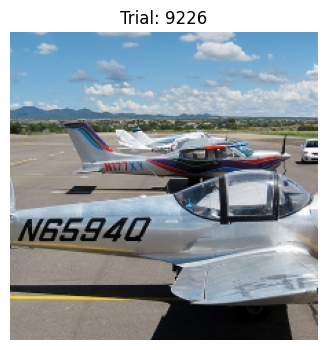

In [ ]:
# Quick Data Preview

train_loader, val_loader, test_loader = get_dataloaders(ll)

print("Fetching one batch to preview data format...")
for voxels, images, trials in train_loader:
    print(f"Voxel Shape: {voxels.shape}")  # [B, 3, Num_Voxels] - 3 repeats
    print(f"Image Shape: {images.shape}")  # [B, C, H, W]

    plt.figure(figsize=(4, 4))
    plt.imshow(images[0].permute(1, 2, 0))
    plt.title(f"Trial: {trials[0].item()}")
    plt.axis("off")
    plt.show()
    break


del train_loader, val_loader, test_loader

# Part 1: Data Loading and Preprocessing

Our goal here is straightforward: produce three clean tensors for each split that we can feed into our models.

## The Data Structure

For each trial we have:
- **X**: fMRI voxels (one vector per trial, ~15k dimensions)
- **I**: The stimulus image the subject was viewing
- **trial_id**: Lets us group repeated presentations of the same stimulus

## Handling Noisy Data

fMRI is inherently noisy. A single voxel measurement contains not just neural signal but also scanner drift, physiological noise (heartbeat, breathing), and random thermal fluctuations. Repeated presentations of the same stimulus are invaluable because they let us separate signal from noise.

We'll use repeats in two different ways depending on the model:
1. **Average repeats** for the linear baseline (reduces noise, cleaner targets)
2. **Expand repeats** for the nonlinear model (treat each repeat as a separate sample, 3× more training data)

In [ ]:
import torch

def to_vae_range(images: torch.Tensor) -> torch.Tensor:
    """
    images: [B,3,H,W], uint8 or float
    returns float32 in [-1,1]
    """
    x = images
    if x.dtype != torch.float32:
        x = x.float()
    if x.max() > 1.5:
        x = x / 255.0
    x = x.clamp(0, 1)
    x = x * 2 - 1
    return x


## Materializing the Dataset

We stream through the WebDataset once and stack everything into tensors. This gives us simple, indexable arrays that work with standard PyTorch training loops.

### Memory Optimization

Images are converted to `uint8` immediately after loading. This saves 4× memory compared to float32 (1 byte vs 4 bytes per pixel), which matters when you're loading thousands of 256×256 RGB images.

### Deterministic Splits

By materializing and shuffling with a fixed seed, we ensure the exact same train/val/test split across runs. This is crucial for reproducibility—you want to know that improvements come from your model, not from lucky data shuffling.

In [ ]:
import numpy as np
from tqdm.auto import tqdm

def take_n_samples(loader, n_samples=None, seed=42):
    """
    Takes n_samples from a streaming WebLoader.
    If n_samples is None, takes all available samples.
    Returns:
      X: [N,V], images: [N,3,H,W] (uint8), trials: [N]
    """
    set_seed(seed)

    xs, ims, trs = [], [], []
    n = 0

    # Add a progress bar. If n_samples is None, total is unknown.
    pbar = tqdm(total=n_samples, desc="Materializing samples", unit="samples")

    for vox, img, trial in loader:
        # Optimize memory: Convert images to uint8 immediately (saves 4x RAM)
        # img comes in as float [0,1]. Scale to [0,255] and cast.
        if img.dtype == torch.float32:
            img = (img * 255).clamp(0, 255).to(torch.uint8)

        b = vox.shape[0]
        xs.append(vox.cpu()) # Keep on CPU to save GPU memory
        ims.append(img.cpu())
        trs.append(trial.cpu())
        n += b
        pbar.update(b)

        if n_samples is not None and n >= n_samples:
            break

    pbar.close()

    if not xs:
        raise ValueError("Loader yielded no data!")

    X = torch.cat(xs, dim=0)
    I = torch.cat(ims, dim=0)
    T = torch.cat(trs, dim=0)

    if n_samples is not None:
        X = X[:n_samples]
        I = I[:n_samples]
        T = T[:n_samples]

    # Shuffle in memory
    perm = torch.randperm(X.shape[0])
    X = X[perm]
    I = I[perm]
    T = T[perm]

    return X, I, T

In [ ]:
# 1. Refresh global dataloaders with the updated config (ll)
train_loader, val_loader, test_loader = get_dataloaders(ll)

# 2. Materialize Data (Using optimized uint8 storage)
# We pass n_samples=None to consume the entire dataset defined by the loaders
print("Materializing Training Data...")
Xtr, Itr, _ = take_n_samples(train_loader, n_samples=None, seed=ll.seed)
print("Materializing Validation Data...")
Xva, Iva, _ = take_n_samples(val_loader,   n_samples=None,   seed=ll.seed + 1)
print("Materializing Test Data...")
Xte, Ite, Tte = take_n_samples(test_loader,  n_samples=None,  seed=ll.seed + 2)

print("Xtr:", Xtr.shape, "Itr:", Itr.shape)
print("Xva:", Xva.shape, "Iva:", Iva.shape)
print("Xte:", Xte.shape, "Ite:", Ite.shape)

Setting up streaming dataloaders for Subject 1...
Loaders ready. Batch size: 64
Materializing Training Data...


Materializing samples: 0samples [00:00, ?samples/s]

Materializing Validation Data...


Materializing samples: 0samples [00:00, ?samples/s]

Materializing Test Data...


Materializing samples: 0samples [00:00, ?samples/s]

Xtr: torch.Size([8640, 3, 15724]) Itr: torch.Size([8640, 3, 224, 224])
Xva: torch.Size([300, 3, 15724]) Iva: torch.Size([300, 3, 224, 224])
Xte: torch.Size([1000, 3, 15724]) Ite: torch.Size([1000, 3, 224, 224])


In [ ]:
#  Prepare TWO versions of voxel data
# AVERAGED: For Ridge regression (reduces noise, better linear fit)
# EXPANDED: For MLPs (use all repeats as separate samples = 3x more data!)

print(f"Original shape: {Xtr.shape}  (N samples × 3 repeats × V voxels)")
N_tr, R, V = Xtr.shape

print("\nCreating AVERAGED data for Ridge...")
Xtr_avg = voxel_select(Xtr, mode="mean")  # [N, V]
Xva_avg = voxel_select(Xva, mode="mean")
Xte_avg = voxel_select(Xte, mode="mean")
print(f"   Xtr_avg: {Xtr_avg.shape}")

print("\nCreating EXPANDED voxels for MLPs (3x samples)...")
Xtr_exp_raw = Xtr.view(N_tr * R, V)  # [N*3, V]
print(f"   Xtr_exp: {Xtr_exp_raw.shape} ({N_tr} samples × {R} repeats = {N_tr * R} total)")

# Validation/test: use averaged (cleaner evaluation)
Xva = Xva_avg
Xte = Xte_avg

# Ridge uses averaged
Xtr = Xtr_avg

def zscore_train_apply(Xtr, Xva, Xte, eps=1e-6):
    # Calculate stats on training set only
    mu = Xtr.mean(dim=0, keepdim=True)
    sd = Xtr.std(dim=0, keepdim=True).clamp_min(eps)
    return (Xtr - mu) / sd, (Xva - mu) / sd, (Xte - mu) / sd, mu, sd

# Apply Z-score to averaged data (for Ridge)
Xtr, Xva, Xte, Xmu, Xsd = zscore_train_apply(Xtr.float(), Xva.float(), Xte.float())

# Apply Z-score to expanded data (for MLPs) using SAME stats
Xtr_exp = (Xtr_exp_raw.float() - Xmu) / Xsd

print(f"\nRidge will use: Xtr {Xtr.shape} (averaged)")
print(f"MLPs will use:  Xtr_exp {Xtr_exp.shape} (3x samples!)")

Original shape: torch.Size([8640, 3, 15724])  (N samples × 3 repeats × V voxels)

Creating AVERAGED data for Ridge...
   Xtr_avg: torch.Size([8640, 15724])

Creating EXPANDED voxels for MLPs (3x samples)...
   Xtr_exp: torch.Size([25920, 15724]) (8640 samples × 3 repeats = 25920 total)

Ridge will use: Xtr torch.Size([8640, 15724]) (averaged)
MLPs will use:  Xtr_exp torch.Size([25920, 15724]) (3x samples!)


## Design Choice: Averaged vs Expanded Voxels

This is one of the most important decisions in the pipeline. We have 3 repeated measurements per image—how should we use them?

**For Ridge (linear model)**: We *average* the repeats. Ridge regression is sensitive to noise, and averaging reduces measurement noise by approximately $\sqrt{3}$. Cleaner inputs lead to more stable weight estimates.

**For MLP (nonlinear model)**: We *expand* the repeats into separate samples. Neural networks are data-hungry and have built-in regularization (dropout, weight decay) to handle noise. More samples—even noisy ones—often help more than cleaner but fewer samples.

This creates an interesting asymmetry: Ridge trains on ~8,640 samples, while MLP trains on ~25,920. The MLP sees noisier data but more of it.

# Part 2: Image Targets via VAE Latents

As we discussed in Notebook 2, predicting raw pixels from fMRI is impractical due to the massive dimensionality mismatch and the harshness of pixel-space losses. Instead, we predict VAE latents: 4,096 dimensions instead of 196,608, with the added benefit that nearby latents correspond to visually similar images.


$$
\text{196,608 pixels} \xrightarrow{\text{VAE}} \text{4,096 latents}
$$


Here we put that into practice. We'll encode all NSD stimulus images into latent space using the same Stable Diffusion VAE from Notebook 2, and these latents become the regression targets that our brain decoders learn to predict from voxels.

In [ ]:
import torch.nn.functional as F
from diffusers import AutoencoderKL
from tqdm.auto import tqdm

@torch.inference_mode()
def encode_latents_sdvae(images: torch.Tensor, vae: AutoencoderKL, img_size: int, batch_size: int = 16):
    """
    returns scaled SD latents: [N, 4, img_size/8, img_size/8]
    """
    sf = float(getattr(vae.config, "scaling_factor", 0.18215))
    out = []
    for i in tqdm(range(0, len(images), batch_size), desc="VAE encode"):
        x = images[i:i+batch_size]
        x = to_vae_range(x).to(device)

        if x.shape[-2:] != (img_size, img_size):
            x = F.interpolate(x, size=(img_size, img_size), mode="bilinear", align_corners=False)

        dist = vae.encode(x).latent_dist
        z = dist.mode() * sf  # deterministic target in SD latent convention
        out.append(z.cpu())

    return torch.cat(out, dim=0)

@torch.inference_mode()
def decode_latents_sdvae(latents: torch.Tensor, vae: AutoencoderKL):
    """
    latents are expected scaled (SD convention). returns images in [0,1]
    """
    sf = float(getattr(vae.config, "scaling_factor", 0.18215))
    z = (latents.to(device) / sf)
    x = vae.decode(z).sample
    x = (x.clamp(-1, 1) + 1) / 2
    return x.cpu()


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Encoding the latents might take a few minutes for a dataset of this size.

In [ ]:
# Encode fresh latents to ensure they match current data order

print("Encoding latents from current images...")
vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()

# Encode averaged images (for Ridge)
print("  Encoding averaged images for Ridge...")
Ztr = encode_latents_sdvae(Itr, vae, ll.img_size, batch_size=16)
Zva = encode_latents_sdvae(Iva, vae, ll.img_size, batch_size=16)
Zte = encode_latents_sdvae(Ite, vae, ll.img_size, batch_size=16)

# Expand latents for MLPs by REPLICATING (no extra VAE encoding!)
# Each of the 3 voxel repeats saw the SAME image, so they share the same latent target
print("  Replicating latents for MLPs (no extra encoding!)...")
Ztr_exp = Ztr.unsqueeze(1).expand(-1, R, -1, -1, -1).reshape(N_tr * R, *Ztr.shape[1:])

vae.to("cpu")
torch.cuda.empty_cache()

print(f"\nZtr (Ridge): {Ztr.shape}")
print(f"Ztr_exp (MLPs): {Ztr_exp.shape}")
print(f"   Zva: {Zva.shape}, Zte: {Zte.shape}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Encoding latents from current images...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

  Encoding averaged images for Ridge...


VAE encode:   0%|          | 0/540 [00:00<?, ?it/s]

VAE encode:   0%|          | 0/19 [00:00<?, ?it/s]

VAE encode:   0%|          | 0/63 [00:00<?, ?it/s]

  Replicating latents for MLPs (no extra encoding!)...

Ztr (Ridge): torch.Size([8640, 4, 32, 32])
Ztr_exp (MLPs): torch.Size([25920, 4, 32, 32])
   Zva: torch.Size([300, 4, 32, 32]), Zte: torch.Size([1000, 4, 32, 32])


## Target Normalization

We z-score the latent targets for the same reason we z-scored the voxels earlier. Dimensions with larger scales would dominate the loss, even if smaller-scale dimensions carry equally important information. Normalizing ensures every latent channel contributes proportionally during training.

In [ ]:
# Target normalization

def zscore_targets_train_apply(Ytr: torch.Tensor, Yva: torch.Tensor, Yte: torch.Tensor, eps: float = 1e-6):
    """Z-score targets using train stats only (per latent dimension)."""
    mu = Ytr.mean(dim=0, keepdim=True)
    sd = Ytr.std(dim=0, keepdim=True).clamp_min(eps)
    return (Ytr - mu) / sd, (Yva - mu) / sd, (Yte - mu) / sd, mu, sd

def unnormalize_targets(Y: torch.Tensor, mu: torch.Tensor, sd: torch.Tensor) -> torch.Tensor:
    return Y * sd + mu


# Part 3: Linear Baseline (Ridge Regression)

Ridge regression is the natural first baseline for brain decoding. fMRI data is high-dimensional (15k voxels), noisy, and highly correlated—exactly the conditions where unregularized linear regression falls apart.

## Why Ridge?

Without regularization, linear regression tries to find weights that perfectly fit the training data. With more voxels than samples, there are infinitely many solutions that achieve zero training error—most of which generalize terribly.

Ridge adds an L2 penalty that shrinks weights toward zero:

$$\arg\min_W \|XW - Z\|_2^2 + \alpha\|W\|_2^2$$

The hyperparameter $\alpha$ controls how much we trust the data versus how much we prefer small weights. Higher $\alpha$ means more shrinkage, more stable predictions, but potentially underfitting.

## A Note on Expectations

If your MLP doesn't beat Ridge, that's not failure. It often means either the relationship is mostly linear, or the MLP is overfitting. Ridge is a strong baseline precisely because it's stable and interpretable. Although in this case spesifically we would expect high-variance methods to do better in general.

In [ ]:
class DualRidge:
    def __init__(self, alpha: float = 1e5):
        self.alpha = alpha
        self.Xtr = None
        self.A = None  # [N,D]

    def fit(self, Xtr: torch.Tensor, Ytr: torch.Tensor):
        """
        Xtr: [N,V]
        Ytr: [N,D]
        """
        Xtr = Xtr.float()
        Ytr = Ytr.float()
        N = Xtr.shape[0]

        K = Xtr @ Xtr.T                       # [N,N]
        K = K + self.alpha * torch.eye(N)     # ridge
        A = torch.linalg.solve(K, Ytr)        # [N,D]

        self.Xtr = Xtr
        self.A = A
        return self

    def predict(self, X: torch.Tensor):
        """
        X: [M,V]
        returns: [M,D]
        """
        X = X.float()
        Kxt = X @ self.Xtr.T                  # [M,N]
        return Kxt @ self.A                   # [M,D]


## The Dual Formulation

We use the "dual" form of ridge regression, which works with an $N \times N$ matrix instead of a $V \times V$ matrix, where $N$ is the number of samples and $V$ is the number of voxels. Since we have many more voxels (15k) than samples (8k), the dual formulation is a little faster to compute. The math isn't critical for this tutorial.

In [ ]:
# Check for shape mismatch between voxels (Xtr) and latents (Ztr)
# This happens if n_train is changed but Ztr is loaded from a stale cache.
if Xtr.shape[0] != Ztr.shape[0]:
    print(f"Shape mismatch detected! Xtr: {Xtr.shape[0]}, Ztr: {Ztr.shape[0]}.")
    print("Re-encoding training latents to match new data size...")

    # Re-load VAE and encode
    vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()
    Ztr = encode_latents_sdvae(Itr, vae, ll.img_size, batch_size=16)

    # Cleanup
    vae.to("cpu")
    torch.cuda.empty_cache()
    print(f"New Ztr shape: {Ztr.shape}")

# --- Flatten latents (targets) ---
Ytr = Ztr.flatten(1)  # [N, 4*32*32] when img_size=256
Yva = Zva.flatten(1)
Yte = Zte.flatten(1)

# --- Normalize targets (improves conditioning, often boosts SSIM) ---
Ytr_n, Yva_n, _, Ymu, Ysd = zscore_targets_train_apply(Ytr.float(), Yva.float(), Yte.float())
print("Target normalization:", "Ymu", tuple(Ymu.shape), "Ysd", tuple(Ysd.shape))

Target normalization: Ymu (1, 4096) Ysd (1, 4096)


## Hyperparameter Tuning: Ridge Alpha

Before fitting our final model, we need to choose the regularization strength $\alpha$. This is Ridge's only hyperparameter, but it matters a lot—too low and the model overfits; too high and it underfits.

We do a simple grid search on the validation set. This is cheap for Ridge (each fit should take about 20-30 seconds) and gives us confidence we're using a reasonable value.

In [ ]:
# Alpha Grid Search
alphas = [10000, 50000, 80000, 100000]
best_alpha = None
best_mse = float("inf")

print(f"Searching for best alpha among: {alphas}...")

for a in alphas:
    # Fit Ridge on normalized targets
    ridge_tmp = DualRidge(alpha=a).fit(Xtr, Ytr_n)
    # Predict on Validation (normalized)
    Yva_hat_tmp_n = ridge_tmp.predict(Xva)
    # MSE in normalized space (comparable across dims)
    mse = torch.mean((Yva_hat_tmp_n - Yva_n)**2).item()
    print(f"Alpha: {a:.0f} | Val MSE (norm): {mse:.6f}")
    if mse < best_mse:
        best_mse = mse
        best_alpha = a

print(f"\nBest Alpha: {best_alpha:.0f} (MSE norm: {best_mse:.6f})")

# Fit final Ridge with best alpha
ridge = DualRidge(alpha=best_alpha).fit(Xtr, Ytr_n)
Yva_hat_n = ridge.predict(Xva)
print("Pred val latent flat (normalized):", Yva_hat_n.shape)

# Unnormalize for reshaping / decoding / metrics
Yva_hat = unnormalize_targets(Yva_hat_n, Ymu, Ysd)
Zva_hat = Yva_hat.view_as(Zva)

Searching for best alpha among: [10000, 50000, 80000, 100000]...
Alpha: 10000 | Val MSE (norm): 0.922566
Alpha: 50000 | Val MSE (norm): 0.875101
Alpha: 80000 | Val MSE (norm): 0.878330
Alpha: 100000 | Val MSE (norm): 0.881239

Best Alpha: 50000 (MSE norm: 0.875101)
Pred val latent flat (normalized): torch.Size([300, 4096])


In [ ]:
print("GT latents:  mean", Zva.mean().item(), "std", Zva.std().item())
print("PRED latents: mean", Zva_hat.mean().item(), "std", Zva_hat.std().item())

# Also compare per-sample norm
gt_n = Zva.flatten(1).norm(dim=1).mean().item()
pr_n = Zva_hat.flatten(1).norm(dim=1).mean().item()
print("Mean ||z||  GT:", gt_n, "PRED:", pr_n)


GT latents:  mean 0.06429699808359146 std 0.8280873894691467
PRED latents: mean 0.06666771322488785 std 0.30145955085754395
Mean ||z||  GT: 52.76652526855469 PRED: 19.226036071777344


## First Results: Ridge Reconstructions

Let's see what our linear baseline produces. The left column shows ground truth (what the VAE itself can reconstruct), and the right shows our predictions from brain activity.

Don't expect photorealism—we're predicting from ~15k noisy voxels. Look for whether the coarse structure (colors, layout, major shapes) is captured.

## Evaluation Metrics

We report multiple metrics because each one can be misleading in different ways.

**Latent MSE** tells us how well we matched the target representation—useful for debugging training, but doesn't directly measure image quality.

**Pixel MSE** is strict per-pixel error after decoding. It penalizes small spatial shifts harshly, even when the image "looks" correct.

**PSNR** (Peak Signal-to-Noise Ratio) is just MSE expressed in decibels. It's easier to compare across different settings but has the same limitations.

**SSIM** (Structural Similarity Index) measures local structure: luminance, contrast, and structural patterns. It often correlates better with human perception than MSE. Two images can have identical MSE but very different SSIM if one preserves structure while the other is uniformly blurry.

The "best" metric depends on your goals. For this tutorial, we focus on SSIM as the primary quality measure.

Decoding first 8 samples for visualization...


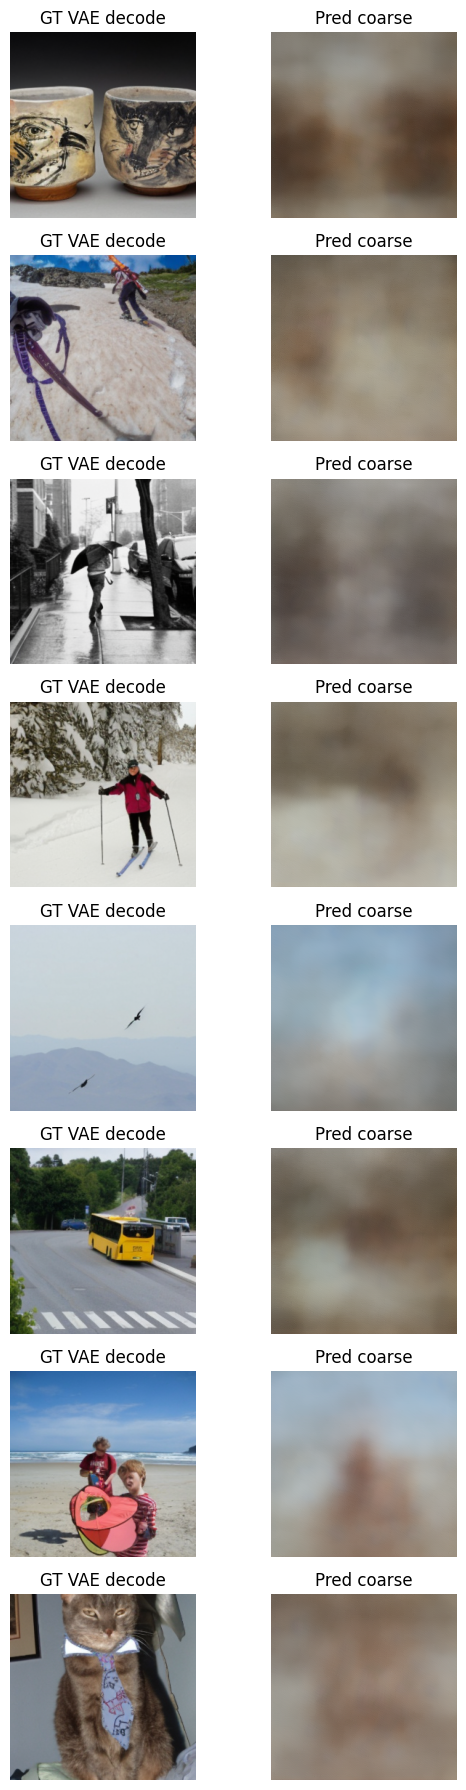


Computing Ridge metrics...
Ridge Latent MSE: 0.587325


Evaluating Ridge:   0%|          | 0/30 [00:00<?, ?it/s]


Ridge Results:
  Pixel  MSE: 0.053438
  SSIM      : 0.3957


In [ ]:
from pytorch_msssim import ssim as compute_ssim
import gc

def resize01(images, size):
    x = images.float()
    if x.max() > 1.5:
        x = x / 255.0
    x = x.clamp(0, 1)
    x = torch.nn.functional.interpolate(x, size=(size, size), mode="bilinear", align_corners=False)
    return x

# Memory Cleanup
gc.collect()
torch.cuda.empty_cache()

# Load VAE once for both visualization and evaluation
vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()

# VISUALIZATION: First 8 samples
print("Decoding first 8 samples for visualization...")
coarse = decode_latents_sdvae(Zva_hat[:8], vae)
gt_viz = decode_latents_sdvae(Zva[:8], vae)

fig, axes = plt.subplots(8, 2, figsize=(6, 18))
for i in range(8):
    axes[i,0].imshow(gt_viz[i].permute(1,2,0).clamp(0,1))
    axes[i,0].set_title("GT VAE decode")
    axes[i,0].axis("off")
    axes[i,1].imshow(coarse[i].permute(1,2,0).clamp(0,1))
    axes[i,1].set_title("Pred coarse")
    axes[i,1].axis("off")
plt.tight_layout()
plt.show()
del coarse, gt_viz
torch.cuda.empty_cache()

# EVALUATION: Full validation set
print("\nComputing Ridge metrics...")

# Compute latent MSE
latent_mse = torch.mean((Zva_hat - Zva) ** 2).item()
print(f"Ridge Latent MSE: {latent_mse:.6f}")

# Prepare ground truth images (keep for MLP evaluation later)
gt_imgs = resize01(Iva, ll.img_size)
del Iva
gc.collect()

# Compute metrics in batches
ssim_scores = []
mse_scores = []
BATCH_SIZE = 10

for batch_start in tqdm(range(0, len(Zva_hat), BATCH_SIZE), desc="Evaluating Ridge"):
    batch_end = min(batch_start + BATCH_SIZE, len(Zva_hat))

    pred_batch = decode_latents_sdvae(Zva_hat[batch_start:batch_end], vae).cpu()
    gt_batch = gt_imgs[batch_start:batch_end]

    for i in range(len(pred_batch)):
        ssim_val = compute_ssim(pred_batch[i:i+1], gt_batch[i:i+1], data_range=1.0, size_average=True).item()
        mse_val = torch.mean((pred_batch[i:i+1] - gt_batch[i:i+1]) ** 2).item()
        ssim_scores.append(ssim_val)
        mse_scores.append(mse_val)

    del pred_batch, gt_batch
    torch.cuda.empty_cache()

pixel_ssim = float(np.mean(ssim_scores))
pixel_mse = float(np.mean(mse_scores))

# Cleanup VAE (keep gt_imgs for MLP)
vae.to("cpu")
del vae
gc.collect()
torch.cuda.empty_cache()

print(f"\nRidge Results:")
print(f"  Pixel  MSE: {pixel_mse:.6f}")
print(f"  SSIM      : {pixel_ssim:.4f}")

# Part 4: Nonlinear Decoder (MLP)

The mapping from voxels to image features might not be purely linear. An MLP lets us capture potential nonlinear interactions between voxels that Ridge misses.

## Key Differences from Ridge

The MLP differs from Ridge in three important ways. First, we expand the training data by treating each of the three voxel repeats as a separate sample, giving us roughly 25,920 training examples instead of 8,640. Neural networks benefit from this because they have the capacity to learn through the noise, whereas Ridge benefits more from cleaner averaged inputs.

Second, we replace the flat output with a CNN upsampler that respects the spatial structure of VAE latents. Ridge predicts each latent dimension independently, but the MLP backbone feeds into convolutional layers that enforce local spatial coherence in the predicted latent maps.

Third, we use aggressive regularization across multiple axes: high dropout, mixup augmentation, input noise, voxel masking, and weight decay. These work together to prevent the network from memorizing training examples while still allowing it to capture nonlinear relationships that Ridge cannot represent.

In [ ]:
@dataclass
class MLPConfig:
    hidden_dims: Tuple[int, ...] = (1024, 2048, 2048)
    dropout: float = 0.4
    lr: float = 1.49e-4
    weight_decay: float = 3.73e-4
    batch_size: int = 128
    epochs: int = 100
    patience: int = 25
    noise_std: float = 0.06
    target_noise: float = 0
    mixup_alpha: float = 0.4
    grad_weight: float = 0.025
    mask_rate: float = 0.2

mlp_cfg = MLPConfig()
print(mlp_cfg)


MLPConfig(hidden_dims=(1024, 2048, 2048), dropout=0.4, lr=0.000149, weight_decay=0.000373, batch_size=128, epochs=100, patience=25, noise_std=0.06, target_noise=0, mixup_alpha=0.4, grad_weight=0.025, mask_rate=0.2)


## MLP Architecture Choices

Our MLP has two stages. The backbone is a standard feedforward network that maps the 15,724-dimensional voxel vector down through three hidden layers (1024, 2048, 2048) to a compact spatial representation. Each hidden layer uses LayerNorm for stable training across voxel dimensions, GELU activations, and dropout at 0.4. The backbone projects to a 64-channel 8x8 feature grid, which a small CNN upsampler then reshapes into the target 4-channel 32x32 latent map through two transposed convolutions.

The CNN upsampler matters because VAE latents have spatial structure. Adjacent positions in the 32x32 latent grid correspond to neighboring image regions. A flat MLP output would predict each of those 4,096 positions independently, ignoring the fact that nearby latent values should be correlated. The CNN head enforces local spatial coherence through its convolutional kernels, producing smoother latent maps that decode into cleaner images. The final output shape is identical to the flat case, so nothing downstream changes.

In [ ]:
import torch.nn as nn

class VoxelMLP(nn.Module):
    """MLP backbone with CNN upsampler for spatially coherent VAE latent prediction."""

    def __init__(self, in_dim: int, out_dim: int, hidden_dims: Tuple[int, ...], dropout: float = 0.1):
        super().__init__()

        layers = []
        prev_dim = in_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.LayerNorm(h_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            ])
            prev_dim = h_dim

        layers.append(nn.Linear(prev_dim, 64 * 8 * 8))
        self.backbone = nn.Sequential(*layers)

        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.GELU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),
            nn.GELU(),
            nn.Conv2d(16, 4, 3, padding=1),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.backbone(x).view(-1, 64, 8, 8)
        return self.upsample(h).flatten(1)

## Spatial Gradient Loss

Beyond simple MSE, we add a loss term that encourages the model to preserve spatial structure in the latent maps. This computes edges in both predicted and target latents using Sobel filters, then penalizes differences. The intuition is that two predictions might have the same MSE, but one preserves sharp boundaries while the other is blurry. The gradient loss prefers the sharp one, which often improves SSIM scores without requiring expensive image-space decoding during training.

In [ ]:
import kornia
def latent_spatial_grad_loss(
    pred_flat: torch.Tensor,
    target_flat: torch.Tensor,
    latent_shape: tuple[int, int, int] = (4, 32, 32),
    reduction: str = "mean",
    loss_type: str = "l1",
    weight: float = 1.0,
) -> torch.Tensor:
    """
    Encourages matching *spatial structure* in latent maps (helps sharpness/SSIM)
    without decoding to pixel space. Very cheap vs VAE-decode losses.

    pred_flat/target_flat: [B, D] where D = C*H*W
    latent_shape: (C,H,W)
    """
    if weight <= 0:
        return pred_flat.new_tensor(0.0)
    C, H, W = latent_shape
    pred = pred_flat.view(-1, C, H, W)
    target = target_flat.view(-1, C, H, W)
    # spatial_gradient returns [B, C, 2, H, W] (dy, dx)
    gp = kornia.filters.spatial_gradient(pred, mode="sobel", order=1)
    gt = kornia.filters.spatial_gradient(target, mode="sobel", order=1)
    if loss_type == "l2":
        base = (gp - gt).pow(2)
        loss = base.mean() if reduction == "mean" else base.sum()
    else:
        base = (gp - gt).abs()
        loss = base.mean() if reduction == "mean" else base.sum()
    return loss * weight

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

def mixup_batch(x: torch.Tensor, y: torch.Tensor, alpha: float = 0.4):
    """Mixup augmentation: blend pairs of samples to create virtual training data."""
    if alpha <= 0:
        return x, y
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)
    index = torch.randperm(batch_size, device=x.device)
    x_mixed = lam * x + (1 - lam) * x[index]
    y_mixed = lam * y + (1 - lam) * y[index]
    return x_mixed, y_mixed

def train_mlp(
    model: nn.Module,
    Xtr: torch.Tensor, Ytr: torch.Tensor,
    Xva: torch.Tensor, Yva: torch.Tensor,
    cfg,
    device: torch.device,
    noise_std: float = 0.1,
    target_noise: float = 0.0,
    mixup_alpha: float = 0.0,
    grad_weight: float = 0.0,
    mask_rate: float = 0.0,
    latent_shape: Optional[Tuple[int, int, int]] = None,
):
    model = model.to(device)

    base_lr = float(getattr(cfg, 'lr', 1e-4))
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs, eta_min=base_lr * 0.01)

    train_ds = TensorDataset(Xtr, Ytr)
    default_workers = 0 if os.name == "nt" else 2
    num_workers = int(getattr(cfg, "num_workers", default_workers))
    train_loader = DataLoader(
        train_ds,
        batch_size=cfg.batch_size,
        shuffle=True,
        pin_memory=(device.type == "cuda"),
        num_workers=num_workers,
        persistent_workers=(num_workers > 0) if num_workers > 0 else False,
    )

    Xva_dev = Xva.to(device)
    Yva_dev = Yva.to(device)

    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'lr': []}

    pbar = tqdm(range(cfg.epochs), desc="Training MLP")

    for epoch in pbar:
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)

            if mixup_alpha > 0:
                xb, yb = mixup_batch(xb, yb, alpha=mixup_alpha)
            if noise_std > 0:
                xb = xb + torch.randn_like(xb) * noise_std
            if target_noise > 0:
                yb = yb + torch.randn_like(yb) * target_noise
            if mask_rate > 0:
                mask = (torch.rand_like(xb) > mask_rate).float()
                xb = xb * mask

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = F.huber_loss(pred, yb)
            if grad_weight > 0 and latent_shape is not None:
                loss = loss + latent_spatial_grad_loss(pred, yb, latent_shape=latent_shape, weight=grad_weight)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        avg_train_loss = float(np.mean(train_losses))

        model.eval()
        with torch.no_grad():
            pred_va = model(Xva_dev)
            val_loss = F.huber_loss(pred_va, Yva_dev).item()

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['lr'].append(current_lr)

        gap = avg_train_loss - val_loss
        pbar.set_postfix({'train': f'{avg_train_loss:.4f}', 'val': f'{val_loss:.4f}', 'gap': f'{gap:.4f}'})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= cfg.patience:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    model.eval()

    print(f"Best val loss: {best_val_loss:.6f}")
    return model, history


## Training Loop and Regularization

Neural networks on fMRI data love to overfit. We use multiple complementary strategies to fight this, and the combination matters more than any single technique.

We train with Huber loss rather than standard MSE. Huber loss behaves like MSE for small errors but switches to L1 for large errors, which prevents individual badly-predicted latent dimensions from dominating the gradient. In practice this produces predictions that are less conservative and more willing to commit to spatial structure, which improves SSIM.

For regularization, we layer several techniques that each address a different failure mode. Mixup blending at $\alpha = 0.4$ creates virtual training examples by interpolating pairs of voxel-latent samples, smoothing the learned mapping and reducing overfitting. Gaussian input noise at $\sigma = 0.06$ prevents the model from memorizing exact voxel values that may reflect scanner noise rather than neural signal. Voxel masking randomly zeros out 20% of input voxels each forward pass, forcing the network to build redundant representations across the voxel population rather than relying on any single voxel. This is conceptually similar to dropout but applied to the input features, and it complements the 0.4 dropout applied to hidden layers.

Early stopping monitors validation loss and restores the best checkpoint if no improvement is seen for 25 epochs. Cosine learning rate decay gradually reduces the learning rate to 1% of its initial value, allowing large early updates to find the general solution and small later updates to refine without overshooting.

## Training the MLP

Now we fit the MLP on the expanded training set and compare against Ridge.

When evaluating, keep in mind that improvements might be metric-specific. The MLP might improve SSIM but worsen pixel MSE, or vice versa. This usually reflects different error modes rather than a contradiction—preserving structure isn't the same as minimizing per-pixel error.

Latent shape: (4, 32, 32)
Training target space: normalized latents
Config: MLPConfig(hidden_dims=(1024, 2048, 2048), dropout=0.4, lr=0.000149, weight_decay=0.000373, batch_size=128, epochs=100, patience=25, noise_std=0.06, target_noise=0, mixup_alpha=0.4, grad_weight=0.025, mask_rate=0.2)
Model params: 30,842,484
Training with EXPANDED data: 25920 samples
Regularization: noise=0.06, target_noise=0, mixup=0.4


Training MLP:   0%|          | 0/100 [00:00<?, ?it/s]


Early stopping at epoch 75
Best val loss: 0.360169


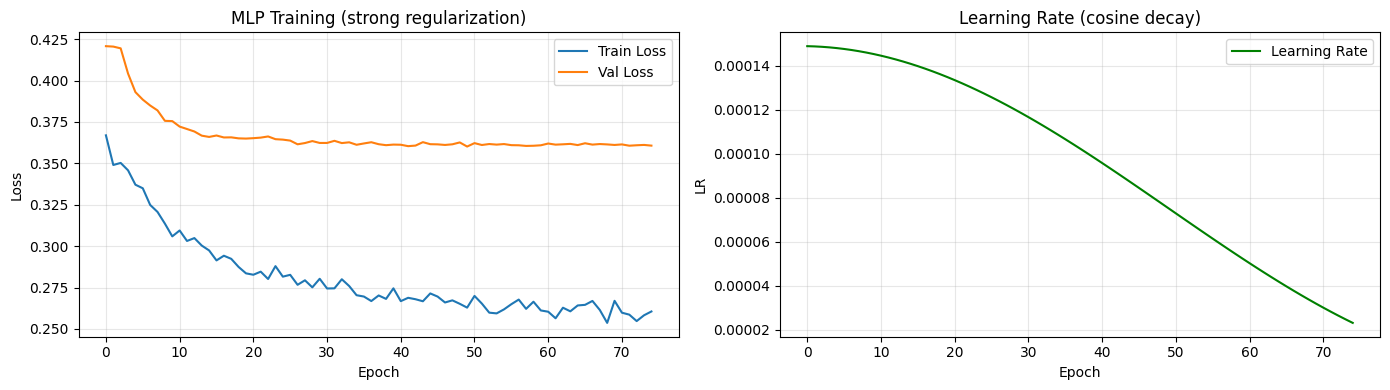

In [ ]:
# Train Simple MLP with strong regularization
set_seed(ll.seed)

latent_shape = (int(Ztr.shape[1]), int(Ztr.shape[2]), int(Ztr.shape[3]))
print("Latent shape:", latent_shape)

# Use expanded data for MLP training (3x samples!)
Ytr_exp_mlp = Ztr_exp.flatten(1).float()
Ytr_exp_mlp_n = (Ytr_exp_mlp - Ymu) / Ysd
print("Training target space: normalized latents")



in_dim  = Xtr.shape[1]
out_dim = Ytr_n.shape[1]
model = VoxelMLP(in_dim, out_dim, mlp_cfg.hidden_dims, mlp_cfg.dropout)
print(f"Config: {mlp_cfg}")
print(f"Model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training with EXPANDED data: {Xtr_exp.shape[0]} samples")
print(f"Regularization: noise={mlp_cfg.noise_std}, target_noise={mlp_cfg.target_noise}, mixup={mlp_cfg.mixup_alpha}")

model, history = train_mlp(
    model,
    Xtr_exp, Ytr_exp_mlp_n,
    Xva, Yva_n,
    mlp_cfg, device,
    noise_std=mlp_cfg.noise_std,
    target_noise=getattr(mlp_cfg, 'target_noise', 0.0),
    mixup_alpha=getattr(mlp_cfg, 'mixup_alpha', 0.0),
    grad_weight=mlp_cfg.grad_weight,
    mask_rate=mlp_cfg.mask_rate,
    latent_shape=latent_shape,
)

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MLP Training (strong regularization)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['lr'], label='Learning Rate', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('LR')
ax2.set_title('Learning Rate (cosine decay)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Generate MLP predictions (in normalized latent space)
model.eval()
with torch.no_grad():
    Yva_hat_mlp_n = model(Xva.to(device)).cpu()

# Unnormalize for decoding/metrics
Yva_hat_mlp = unnormalize_targets(Yva_hat_mlp_n, Ymu, Ysd)
Zva_hat_mlp = Yva_hat_mlp.view_as(Zva)

print("MLP predicted latents:")
print(f"  mean: {Zva_hat_mlp.mean().item():.4f}, std: {Zva_hat_mlp.std().item():.4f}")
print(f"  GT mean: {Zva.mean().item():.4f}, GT std: {Zva.std().item():.4f}")


MLP predicted latents:
  mean: 0.0734, std: 0.3894
  GT mean: 0.0643, GT std: 0.8281


In [ ]:
# Evaluate MLP predictions (batched for speed)
print("Evaluating MLP predictions...")

# Compute latent MSE
latent_mse_mlp = torch.mean((Zva_hat_mlp - Zva) ** 2).item()

# Load VAE and compute metrics in batches
vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()

ssim_scores_mlp = []
mse_scores_mlp = []
BATCH_SIZE = 10

for batch_start in tqdm(range(0, len(Zva_hat_mlp), BATCH_SIZE), desc="Evaluating MLP"):
    batch_end = min(batch_start + BATCH_SIZE, len(Zva_hat_mlp))

    pred_batch = decode_latents_sdvae(Zva_hat_mlp[batch_start:batch_end], vae).cpu()
    gt_batch = gt_imgs[batch_start:batch_end]

    for i in range(len(pred_batch)):
        ssim_val = compute_ssim(pred_batch[i:i+1], gt_batch[i:i+1], data_range=1.0, size_average=True).item()
        mse_val = torch.mean((pred_batch[i:i+1] - gt_batch[i:i+1]) ** 2).item()
        ssim_scores_mlp.append(ssim_val)
        mse_scores_mlp.append(mse_val)

    del pred_batch, gt_batch
    torch.cuda.empty_cache()

pixel_ssim_mlp = float(np.mean(ssim_scores_mlp))
pixel_mse_mlp = float(np.mean(mse_scores_mlp))

# Cleanup
vae.to("cpu")
del vae, gt_imgs  # Now we can delete gt_imgs
gc.collect()
torch.cuda.empty_cache()

print("\nMLP Results:")
print(f"  Latent MSE: {latent_mse_mlp:.6f}")
print(f"  Pixel  MSE: {pixel_mse_mlp:.6f}")
print(f"  SSIM      : {pixel_ssim_mlp:.4f}")

print("\nRidge Results (for comparison):")
print(f"  Latent MSE: {latent_mse:.6f}")
print(f"  SSIM      : {pixel_ssim:.4f}")

improvement = (pixel_ssim_mlp - pixel_ssim) / max(pixel_ssim, 1e-8) * 100
print(f"\nSSIM change vs Ridge: {improvement:+.2f}%")

Evaluating MLP predictions...


Evaluating MLP:   0%|          | 0/30 [00:00<?, ?it/s]


MLP Results:
  Latent MSE: 0.559539
  Pixel  MSE: 0.050969
  SSIM      : 0.4074

Ridge Results (for comparison):
  Latent MSE: 0.587325
  SSIM      : 0.3957

SSIM change vs Ridge: +2.96%


## Validation Summary: Ridge vs MLP

Both models have their strengths.

**Ridge** is fast, stable, and interpretable. It uses repeat-averaged data and has a single hyperparameter. When the underlying relationship is mostly linear, Ridge is hard to beat.

**MLP** can capture nonlinear interactions and uses 3× more training data (expanded repeats). But it requires careful regularization and early stopping to avoid memorizing the training set.

The validation comparison tells us which approach works better for this subject and dataset. But the real test comes next—evaluating on completely held-out data.

In [ ]:
# --- Summary ---
print("=" * 60)
print("LOW-LEVEL BRAIN DECODING SUMMARY")
print("=" * 60)
print()
print("Approach: Decode VAE latents from fMRI voxels")
print(f"Subject: {ll.subject_id}")
print(f"Train samples: {len(Xtr)}")
print(f"Val samples: {len(Xva)}")
print()
print("MODELS:")
print(f"  1. Ridge Regression (alpha={ll.ridge_alpha:.0f})")
print(f"  2. MLP (neural network)")
print()
print("VALIDATION RESULTS:")
print(f"  Ridge:  SSIM = {pixel_ssim:.4f}")
print(f"  MLP:    SSIM = {pixel_ssim_mlp:.4f}")
print()
improvement = (pixel_ssim_mlp - pixel_ssim) / max(pixel_ssim, 1e-8) * 100
print(f"MLP improvement over Ridge: {improvement:+.2f}%")
print("=" * 60)


LOW-LEVEL BRAIN DECODING SUMMARY

Approach: Decode VAE latents from fMRI voxels
Subject: 1
Train samples: 8640
Val samples: 300

MODELS:
  1. Ridge Regression (alpha=100000)
  2. MLP (neural network)

VALIDATION RESULTS:
  Ridge:  SSIM = 0.3957
  MLP:    SSIM = 0.4074

MLP improvement over Ridge: +2.96%


# Part 5: Final Test Set Evaluation

The test set contains images never used during training or model selection. This is the only place where we should report "final" metrics—everything before this was tuning and comparison.

We'll decode both Ridge and MLP predictions back to images, compute metrics across all test samples, and visualize reconstructions for qualitative assessment. Numbers tell part of the story; seeing actual images tells the rest.

In [ ]:
from pytorch_msssim import ssim as compute_ssim
import torch.nn.functional as F
import gc

# Memory Cleanup
gc.collect()
torch.cuda.empty_cache()

print("Evaluating on TEST SET")
print(f"   Test samples: {len(Xte)}")

# Generate latent predictions on TEST set
print("\nGenerating predictions...")
Yte_ridge = ridge.predict(Xte)
Yte_ridge_unnorm = unnormalize_targets(torch.tensor(Yte_ridge).float(), Ymu, Ysd)
Zte_hat_ridge = Yte_ridge_unnorm.view(-1, *Zte.shape[1:])
del Yte_ridge, Yte_ridge_unnorm
gc.collect()

model.eval()
with torch.no_grad():
    Yte_hat_mlp_n = model(Xte.to(device)).cpu()
Yte_hat_mlp = unnormalize_targets(Yte_hat_mlp_n, Ymu, Ysd)
Zte_hat_mlp = Yte_hat_mlp.view(-1, *Zte.shape[1:])
del Yte_hat_mlp_n, Yte_hat_mlp
gc.collect()


vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()

# Store metrics for each sample
all_metrics = []
batch_size = 10

for batch_start in tqdm(range(0, len(Zte), batch_size), desc="Test evaluation"):
    batch_end = min(batch_start + batch_size, len(Zte))

    # Decode batch for Ridge, MLP, and GT
    pred_ridge_batch = decode_latents_sdvae(Zte_hat_ridge[batch_start:batch_end], vae).cpu()
    pred_mlp_batch = decode_latents_sdvae(Zte_hat_mlp[batch_start:batch_end], vae).cpu()
    gt_batch = decode_latents_sdvae(Zte[batch_start:batch_end], vae).cpu()

    # Compute metrics for each sample in batch
    for i in range(len(gt_batch)):
        idx = batch_start + i
        pred_ridge = pred_ridge_batch[i:i+1]
        pred_mlp = pred_mlp_batch[i:i+1]
        gt = gt_batch[i:i+1]

        ridge_ssim = compute_ssim(pred_ridge, gt, data_range=1.0, size_average=True).item()
        ridge_mse = F.mse_loss(pred_ridge, gt).item()
        ridge_psnr = 10 * np.log10(1.0 / max(ridge_mse, 1e-10))

        mlp_ssim = compute_ssim(pred_mlp, gt, data_range=1.0, size_average=True).item()
        mlp_mse = F.mse_loss(pred_mlp, gt).item()
        mlp_psnr = 10 * np.log10(1.0 / max(mlp_mse, 1e-10))

        all_metrics.append({
            'idx': idx,
            'ridge_ssim': ridge_ssim, 'ridge_psnr': ridge_psnr, 'ridge_mse': ridge_mse,
            'mlp_ssim': mlp_ssim, 'mlp_psnr': mlp_psnr, 'mlp_mse': mlp_mse
        })

    # Cleanup batch
    del pred_ridge_batch, pred_mlp_batch, gt_batch
    torch.cuda.empty_cache()
    gc.collect()

# Cleanup VAE
vae.to("cpu")
del vae
gc.collect()
torch.cuda.empty_cache()

# Aggregate and Print Summary Metrics
ridge_ssims = np.array([m['ridge_ssim'] for m in all_metrics])
mlp_ssims = np.array([m['mlp_ssim'] for m in all_metrics])
ridge_psnrs = np.array([m['ridge_psnr'] for m in all_metrics])
mlp_psnrs = np.array([m['mlp_psnr'] for m in all_metrics])
ridge_mses = np.array([m['ridge_mse'] for m in all_metrics])
mlp_mses = np.array([m['mlp_mse'] for m in all_metrics])

print("\n" + "=" * 70)
print(f"TEST SET METRICS (All {len(all_metrics)} Samples)")
print("=" * 70)
print(f"{'Metric':<12} {'Ridge':<25} {'Simple MLP':<25}")
print("-" * 70)
print(f"{'SSIM':<12} {ridge_ssims.mean():.4f} +/- {ridge_ssims.std():.4f}        {mlp_ssims.mean():.4f} +/- {mlp_ssims.std():.4f}")
print(f"{'PSNR':<12} {ridge_psnrs.mean():.2f} +/- {ridge_psnrs.std():.2f} dB       {mlp_psnrs.mean():.2f} +/- {mlp_psnrs.std():.2f} dB")
print(f"{'MSE':<12} {ridge_mses.mean():.5f} +/- {ridge_mses.std():.5f}    {mlp_mses.mean():.5f} +/- {mlp_mses.std():.5f}")
print("=" * 70)

# Compute improvement
ssim_diff = mlp_ssims.mean() - ridge_ssims.mean()
ssim_pct = ssim_diff / ridge_ssims.mean() * 100
print(f"\nMLP vs Ridge: SSIM {ssim_diff:+.4f} ({ssim_pct:+.2f}%)")
print(f"   MLP wins on {np.sum(mlp_ssims > ridge_ssims)}/{len(mlp_ssims)} samples ({np.sum(mlp_ssims > ridge_ssims)/len(mlp_ssims)*100:.1f}%)")

Evaluating on TEST SET
   Test samples: 1000

Generating predictions...


/tmp/ipykernel_16156/3269786141.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Yte_ridge_unnorm = unnormalize_targets(torch.tensor(Yte_ridge).float(), Ymu, Ysd)



Computing metrics in batches of 10 (memory-efficient)...


Test evaluation:   0%|          | 0/100 [00:00<?, ?it/s]


TEST SET METRICS (All 1000 Samples)
Metric       Ridge                     Simple MLP               
----------------------------------------------------------------------
SSIM         0.4351 +/- 0.1403        0.4462 +/- 0.1418
PSNR         13.29 +/- 1.82 dB       13.49 +/- 1.81 dB
MSE          0.05092 +/- 0.02028    0.04868 +/- 0.01985

MLP vs Ridge: SSIM +0.0111 (+2.55%)
   MLP wins on 800/1000 samples (80.0%)


## Visual Inspection

Metrics are useful but incomplete. Reconstructions can fail in ways that metrics don't capture, and they can succeed in ways that metrics undervalue.

When examining reconstructions, look for:
- Do edges roughly align with the original?
- Are colors plausible (not inverted or shifted)?
- Does the reconstruction show meaningful structure, or has it collapsed to an average-looking blob?

When comparing Ridge and MLP, look for *systematic* differences rather than cherry-picking individual examples where one method happened to do better.

In [ ]:
# Select 50 random samples from TEST set
np.random.seed(42)
n_samples = min(50, len(all_metrics))
random_indices = np.random.choice(len(all_metrics), size=n_samples, replace=False)
random_indices = np.sort(random_indices)

# Get metrics for selected samples
metrics_50 = [all_metrics[idx] for idx in random_indices]

# Decode selected samples for visualization
print(f"Decoding {n_samples} samples for visualization...")
vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()

viz_samples = []
for idx in tqdm(random_indices, desc="Decoding viz samples"):
    ridge_img = decode_latents_sdvae(Zte_hat_ridge[idx:idx+1], vae).cpu()
    mlp_img = decode_latents_sdvae(Zte_hat_mlp[idx:idx+1], vae).cpu()
    gt_img = decode_latents_sdvae(Zte[idx:idx+1], vae).cpu()
    viz_samples.append((gt_img[0], ridge_img[0], mlp_img[0]))

vae.to("cpu")
del vae
gc.collect()
torch.cuda.empty_cache()

samples_per_row = 5
n_rows = (n_samples + samples_per_row - 1) // samples_per_row

fig, axes = plt.subplots(n_rows, samples_per_row * 3, figsize=(samples_per_row * 6, n_rows * 2.2))

for i, (gt, ridge, mlp) in enumerate(viz_samples):
    row = i // samples_per_row
    col_base = (i % samples_per_row) * 3

    m = metrics_50[i]
    idx = random_indices[i]

    # Ground Truth
    ax_gt = axes[row, col_base]
    ax_gt.imshow(gt.permute(1, 2, 0).clamp(0, 1))
    ax_gt.set_title(f"GT #{idx}", fontsize=8)
    ax_gt.axis('off')

    # Ridge
    ax_ridge = axes[row, col_base + 1]
    ax_ridge.imshow(ridge.permute(1, 2, 0).clamp(0, 1))
    ax_ridge.set_title(f"Ridge\n{m['ridge_ssim']:.3f}", fontsize=7)
    ax_ridge.axis('off')

    # MLP
    ax_mlp = axes[row, col_base + 2]
    ax_mlp.imshow(mlp.permute(1, 2, 0).clamp(0, 1))
    ax_mlp.set_title(f"MLP\n{m['mlp_ssim']:.3f}", fontsize=7)
    ax_mlp.axis('off')

# Hide any unused axes
for i in range(len(viz_samples), n_rows * samples_per_row):
    row = i // samples_per_row
    col_base = (i % samples_per_row) * 3
    for j in range(3):
        axes[row, col_base + j].axis('off')

plt.suptitle("TEST SET: 50 Random Samples - Ground Truth | Ridge (SSIM) | MLP (SSIM)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Displayed {n_samples} randomly selected TEST reconstructions")


Output hidden; open in https://colab.research.google.com to view.

# Part 6: Saving Low-Level Reconstructions

We need to save our low-level reconstructions for use in the high-level pipeline. The next notebook will use these blurry reconstructions as a starting point for diffusion-based refinement (img2img).

We'll generate predictions for the **test set** using our best model (MLP), then save them in a format that's easy to load later. The downstream notebooks (Notebook 5) only need test set reconstructions.

## Storage Options

**Google Drive (Recommended)**: If you're running on Colab, mounting your Drive makes it easy to persist outputs across sessions and share between notebooks.

**Local Storage**: If you're running locally or prefer not to use Drive, we'll save to a local directory that you can download manually.

## Memory Cleanup Before Part 6

Before we start saving, let's clean up large temporary variables we no longer need to free up RAM. The expanded training data and intermediate predictions can be deleted.

In [ ]:
import gc

print("Cleaning up memory before Part 6...\n")

# Variables to delete - expanded data and intermediate predictions
# We keep: model, Zte_hat_mlp (for saving), Xmu/Xsd/Ymu/Ysd (normalization)
vars_to_delete = [
    # Expanded training data (large!)
    'Xtr_exp', 'Ztr_exp', 'Ytr_exp_mlp_n',
    # Validation predictions (already evaluated)
    'Zva_hat', 'Zva_hat_mlp',
    # Ridge test predictions (we only save MLP)
    'Zte_hat_ridge',
    # Training voxels (not needed for saving test predictions)
    'Xtr',
    # Original images (should already be encoded to latents)
    'Itr', 'Ite',
    # Ground truth images (used during evaluation)
    'gt_imgs', 'Iva',
]

print("Deleting intermediate artifacts:")
total_freed = 0
for var_name in vars_to_delete:
    if var_name in globals():
        var = globals()[var_name]
        if hasattr(var, 'numel') and hasattr(var, 'element_size'):
            size_mb = var.numel() * var.element_size() / 1e6
            print(f"  {var_name}: {var.shape} = {size_mb:.1f} MB")
            total_freed += size_mb
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"Total freed: ~{total_freed:.0f} MB")
print(f"{'='*60}")

# Show what we're keeping for saving
print("\nKept for Part 6:")
kept_vars = ['model', 'Zte_hat_mlp', 'Zte', 'Xmu', 'Xsd', 'Ymu', 'Ysd', 'Tte']
for var_name in kept_vars:
    if var_name in globals():
        var = globals()[var_name]
        if hasattr(var, 'numel'):
            size_mb = var.numel() * var.element_size() / 1e6
            print(f"  {var_name}: {size_mb:.1f} MB")
        else:
            print(f"  {var_name}: (model)")

print("\nMemory cleanup complete! ✓")

Cleaning up memory before Part 6...

Deleting intermediate artifacts:
  Xtr_exp: torch.Size([25920, 15724]) = 1630.3 MB
  Ztr_exp: torch.Size([25920, 4, 32, 32]) = 424.7 MB
  Ytr_exp_mlp_n: torch.Size([25920, 4096]) = 424.7 MB
  Zva_hat: torch.Size([300, 4, 32, 32]) = 4.9 MB
  Zva_hat_mlp: torch.Size([300, 4, 32, 32]) = 4.9 MB
  Zte_hat_ridge: torch.Size([1000, 4, 32, 32]) = 16.4 MB
  Xtr: torch.Size([8640, 15724]) = 543.4 MB
  Itr: torch.Size([8640, 3, 224, 224]) = 1300.6 MB
  Ite: torch.Size([1000, 3, 224, 224]) = 150.5 MB

Total freed: ~4500 MB

Kept for Part 6:
  model: (model)
  Zte_hat_mlp: 16.4 MB
  Zte: 16.4 MB
  Xmu: 0.1 MB
  Xsd: 0.1 MB
  Ymu: 0.0 MB
  Ysd: 0.0 MB
  Tte: 0.0 MB

Memory cleanup complete! ✓


In [ ]:
USE_DRIVE = True

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        SAVE_DIR = Path('/content/drive/MyDrive/NSD_Reconstructions')
        print("Google Drive mounted successfully!")
    except ImportError:
        print("Not running on Colab. Falling back to local storage.")
        USE_DRIVE = False
        SAVE_DIR = RESULTS_DIR / "reconstructions"
else:
    SAVE_DIR = RESULTS_DIR / "reconstructions"

# Create output directories
SAVE_DIR.mkdir(parents=True, exist_ok=True)
LATENTS_DIR = SAVE_DIR / f"subj{ll.subject_id:02d}" / "latents"
IMAGES_DIR = SAVE_DIR / f"subj{ll.subject_id:02d}" / "images"
LATENTS_DIR.mkdir(parents=True, exist_ok=True)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saving outputs to: {SAVE_DIR}")
print(f"  Latents: {LATENTS_DIR}")
print(f"  Images:  {IMAGES_DIR}")

Mounted at /content/drive
Google Drive mounted successfully!
Saving outputs to: /content/drive/MyDrive/NSD_Reconstructions
  Latents: /content/drive/MyDrive/NSD_Reconstructions/subj01/latents
  Images:  /content/drive/MyDrive/NSD_Reconstructions/subj01/images


## Reusing Test Set Predictions

We already generated MLP predictions on the test set in Part 5 (`Zte_hat_mlp`). We'll reuse those predictions for decoding—no need to recompute.

In [ ]:
# Reuse predictions from Part 5 (already computed as Zte_hat_mlp)
print("Reusing MLP test predictions from Part 5...")

if 'Zte_hat_mlp' in dir():
    Zte_hat_final = Zte_hat_mlp
    print(f"  Test latents: {Zte_hat_final.shape}")
else:
    # Fallback: regenerate if Part 5 was skipped
    print("  Zte_hat_mlp not found, regenerating...")
    model.eval()
    with torch.no_grad():
        Yte_hat_n = model(Xte.to(device)).cpu()
        Yte_hat = unnormalize_targets(Yte_hat_n, Ymu, Ysd)
        Zte_hat_final = Yte_hat.view(-1, *Zte.shape[1:])
        print(f"    Test latents: {Zte_hat_final.shape}")

print("Ready for decoding!")

Reusing MLP test predictions from Part 5...
  Test latents: torch.Size([1000, 4, 32, 32])
Ready for decoding!


## Decoding Test Latents to Images

We decode the **test set** predictions to pixel space for use in Notebook 5's hybrid reconstruction. The VAE decoder converts our 4×32×32 latents to 3×256×256 RGB images.


In [ ]:
import gc

# Step 1: Ensure test latents are on CPU
print("Preparing for decoding...")
if Zte_hat_final.is_cuda:
    Zte_hat_final = Zte_hat_final.cpu()
print(f"  Test latents: {Zte_hat_final.shape} on {Zte_hat_final.device}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Step 2: Create output directory
TEMP_DIR = SAVE_DIR / "temp_decode"
TEMP_DIR.mkdir(parents=True, exist_ok=True)

# Step 3: Load VAE
print("\nLoading VAE...")
vae = AutoencoderKL.from_pretrained(ll.vae_id).to(device).eval()


# Step 4: Decode in small batches
# decode_latents_sdvae handles unscaling and [0,1] conversion
print(f"\nDecoding {len(Zte_hat_final)} test images...")
BATCH_SIZE = 16
test_chunks = []

for i in tqdm(range(0, len(Zte_hat_final), BATCH_SIZE), desc="Decoding"):
    batch = Zte_hat_final[i:i+BATCH_SIZE].to(device)

    with torch.no_grad():
        decoded = decode_latents_sdvae(batch, vae)

    # Save batch to disk
    chunk_path = TEMP_DIR / f"test_recon_batch_{i:05d}.pt"
    torch.save(decoded, chunk_path)
    test_chunks.append(chunk_path)

    del decoded, batch
    torch.cuda.empty_cache()

# Step 5: Cleanup VAE
del vae
gc.collect()
torch.cuda.empty_cache()

print(f"\n✓ Decoded test set saved to: {TEMP_DIR}")
print(f"  {len(test_chunks)} batch files created")
print(f"  Output format: [0, 1] RGB tensors")

Preparing for decoding...
  Test latents: torch.Size([1000, 4, 32, 32]) on cpu

Loading VAE...

Decoding 1000 test images...


Decoding:   0%|          | 0/63 [00:00<?, ?it/s]


✓ Decoded test set saved to: /content/drive/MyDrive/NSD_Reconstructions/temp_decode
  63 batch files created
  Output format: [0, 1] RGB tensors


## Saving Model and Artifacts

We save the model weights, normalization parameters, and test set latents. The decoded test images were already saved during the decoding step above.

This allows you to regenerate predictions for any split if needed later.

In [ ]:
print("Saving model and test latents...")

# Ensure directories exist (in case Drive was remounted or paths changed)
LATENTS_DIR.mkdir(parents=True, exist_ok=True)

if 'Zte_hat_final' in globals():
    latents_dict = {
        "test": Zte_hat_final,
    }
    # Add ground truth if available
    if 'Zte' in globals():
        latents_dict["test_gt"] = Zte
    # Trial IDs for matching
    if 'Tte' in globals():
        latents_dict["test_trials"] = Tte

    latents_path = LATENTS_DIR / "test_latents.pt"
    torch.save(latents_dict, latents_path)
    print(f"Saved test latents: {latents_path}")
    print(f"  File size: {latents_path.stat().st_size / 1e6:.1f} MB")
else:
    print("Test latents not found - they may have been deleted.")

if 'model' in globals():
    model_dir = SAVE_DIR / f"subj{ll.subject_id:02d}"
    model_dir.mkdir(parents=True, exist_ok=True)
    model_path = model_dir / "mlp_model.pt"
    torch.save({
        "model_state_dict": model.state_dict(),
        "model_config": {
            "in_dim": 15724,  # NSD fMRI voxels
            "out_dim": 4096,  # 4*32*32 latents
            "hidden_dims": mlp_cfg.hidden_dims,
            "dropout": mlp_cfg.dropout,
        },
        "normalization": {
            "Xmu": Xmu if 'Xmu' in globals() else None,
            "Xsd": Xsd if 'Xsd' in globals() else None,
            "Ymu": Ymu if 'Ymu' in globals() else None,
            "Ysd": Ysd if 'Ysd' in globals() else None,
        },
        "config": {
            "subject_id": ll.subject_id,
            "img_size": ll.img_size,
            "vae_id": ll.vae_id,
        },
    }, model_path)
    print(f"Saved model: {model_path}")
else:
    print("Model not found - it may have been deleted.")

print("Saved model and test latents!")
print(f"Decoded test images are in: {TEMP_DIR}")

Saving model and test latents...
Saved test latents: /content/drive/MyDrive/NSD_Reconstructions/subj01/latents/test_latents.pt
  File size: 32.8 MB
Saved model: /content/drive/MyDrive/NSD_Reconstructions/subj01/mlp_model.pt
Saved model and test latents!
Decoded test images are in: /content/drive/MyDrive/NSD_Reconstructions/temp_decode


## What's Next?

We've created and saved our low-level reconstructions for the test set (~1,000 images). They don't look like much right now—just blurry approximations of color and layout—but they capture the essential low-level structure that the brain encodes.

In [Notebook 4: High-Level Pipeline](https://colab.research.google.com/drive/1sRib_g6UcE6khgj3Ho_4dMWG9oP-4GUP), we'll build a **high-level (semantic) pipeline** that predicts CLIP embeddings from brain activity. CLIP embeddings capture meaning—they know that dogs and wolves are similar but distinct, that cars belong on roads, that faces have eyes. By combining low-level appearance with high-level semantics, we'll produce reconstructions that not only look right but show the right content.

The low-level reconstructions we just saved will serve as the starting point for **img2img diffusion**—we'll noise them slightly and then denoise with semantic guidance from CLIP. This is exactly how state-of-the-art methods like MindEye work: parallel pipelines for appearance and meaning, combined through diffusion-based image generation.